<a href="https://colab.research.google.com/github/Shrrry/CODETECH-IT-SOLUTION-projects/blob/main/Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-surprise --no-cache-dir


Model Evaluation:
RMSE: 0.4117

Top 5 Recommended Items for User 11:

Item 505 | Estimated Rating: 3.9
Item 503 | Estimated Rating: 3.88
Item 504 | Estimated Rating: 3.74


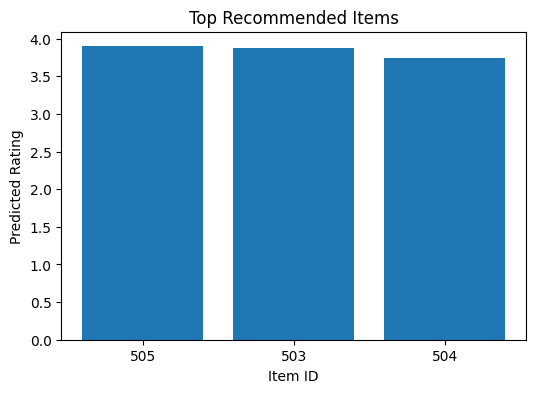

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

# Step 1: Create User-Item Rating Dataset

ratings_data = {
    "user":  [11,11,12,12,13,14,15,15,16,17,18],
    "item":  [501,502,501,503,504,502,503,504,505,501,505],
    "rating":[4,5,3,4,2,5,4,3,5,2,4]
}

ratings_df = pd.DataFrame(ratings_data)

# Step 2: Load Data into Surprise


reader = Reader(rating_scale=(1, 5))
dataset = Dataset.load_from_df(
    ratings_df[["user", "item", "rating"]],
    reader
)

trainset, testset = train_test_split(
    dataset,
    test_size=0.2,
    random_state=42
)

# Step 3: Train SVD Model


svd_model = SVD(n_factors=50, random_state=42)
svd_model.fit(trainset)

# Step 4: Evaluate Model

predictions = svd_model.test(testset)

print("\nModel Evaluation:")
accuracy.rmse(predictions)

# Step 5: Generate Recommendations

target_user = 11

all_items = ratings_df["item"].unique()

# Items already rated by user
rated_items = ratings_df[ratings_df["user"] == target_user]["item"].tolist()

recommendations = []

for product in all_items:
    if product not in rated_items:
        predicted_rating = svd_model.predict(target_user, product).est
        recommendations.append((product, predicted_rating))

# Sort by highest predicted rating
recommendations.sort(key=lambda x: x[1], reverse=True)


# Step 6: Display Top 5 Recommendations

top_n = 5

print(f"\nTop {top_n} Recommended Items for User {target_user}:\n")

for item, score in recommendations[:top_n]:
    print(f"Item {item} | Estimated Rating: {round(score, 2)}")

# Step 7: Visualization

plt.figure(figsize=(6,4))

plt.bar(
    [str(item) for item, _ in recommendations[:top_n]],
    [score for _, score in recommendations[:top_n]]
)

plt.title("Top Recommended Items")
plt.xlabel("Item ID")
plt.ylabel("Predicted Rating")
plt.show()